<a href="https://colab.research.google.com/github/ShailenB/POC/blob/main/Jamboree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# impoting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import ttest_ind
import statsmodels.api as sm
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#	Observations on shape of data, data types of all the attributes, missing value detection, duplicate entries. Re-type of categorical attributes to 'category' (If required), statistical summary.

- Load the dataset as a pandas dataframe 'df'.
- Determining the shape of df

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Jamboree_Admission.csv')
df.shape

(500, 9)

Null/ missing values for different columns:

In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


Determining duplicates:

In [ ]:
df.duplicated().sum()

0

- Determining data types for all the columns

In [ ]:
df.dtypes

,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64


Determining unique assignments in different columns.

In [ ]:
for i in df.columns:
  print('Number of unique assignments for ', i, 'are:', len(df[i].unique()))

Number of unique assignments for  Serial No. are: 500
Number of unique assignments for  GRE Score are: 49
Number of unique assignments for  TOEFL Score are: 29
Number of unique assignments for  University Rating are: 5
Number of unique assignments for  SOP are: 9
Number of unique assignments for  LOR  are: 9
Number of unique assignments for  CGPA are: 184
Number of unique assignments for  Research are: 2
Number of unique assignments for  Chance of Admit  are: 61


Number of unique assignments for  Serial No. are: 500 ->
- 'Serial no.' is the unique identifier for different rows, hence need to be excluded from analyses.
- Stastical summary of numeric columns the dataset

Columns 'University Rating', 'SOP', 'LOR', and 'Research' have small number of unique assignments, hence qualify to be re-typed as category.

In [ ]:
df.loc[:,df.columns != 'Serial No.'].describe().T

,count,mean,std,min,25%,50%,75%,max
GRE Score,500.0,316.47200,11.295148,290.00,308.0000,317.00,325.00,340.00
TOEFL Score,500.0,107.19200,6.081868,92.00,103.0000,107.00,112.00,120.00
CGPA,500.0,8.57644,0.604813,6.80,8.1275,8.56,9.04,9.92
Chance of Admit,500.0,0.72174,0.141140,0.34,0.6300,0.72,0.82,0.97


In [ ]:
cat=['University Rating', 'SOP', 'LOR ', 'Research']
for i in cat:
  df[i]=df[i].astype('category')

Visual inspection of data:

Univariate analyses:

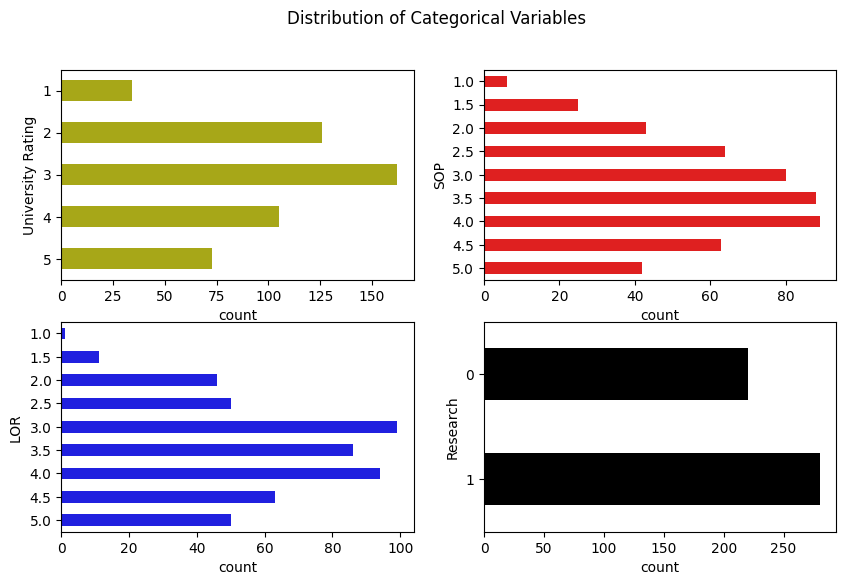

In [ ]:
# Categorical data:
fig, ax =plt.subplots(2,2)
fig.set_size_inches(10,6)
plt.suptitle('Distribution of Categorical Variables')
sns.countplot(df['University Rating'], ax=ax[0][0], color='y', width=0.5)
sns.countplot(df['SOP'], ax=ax[0][1], color='r',width=0.5)
sns.countplot(df['LOR '], ax=ax[1][0], color='b', width=0.5)
sns.countplot(df['Research'], ax=ax[1][1], color='k', width=0.5)
plt.show()

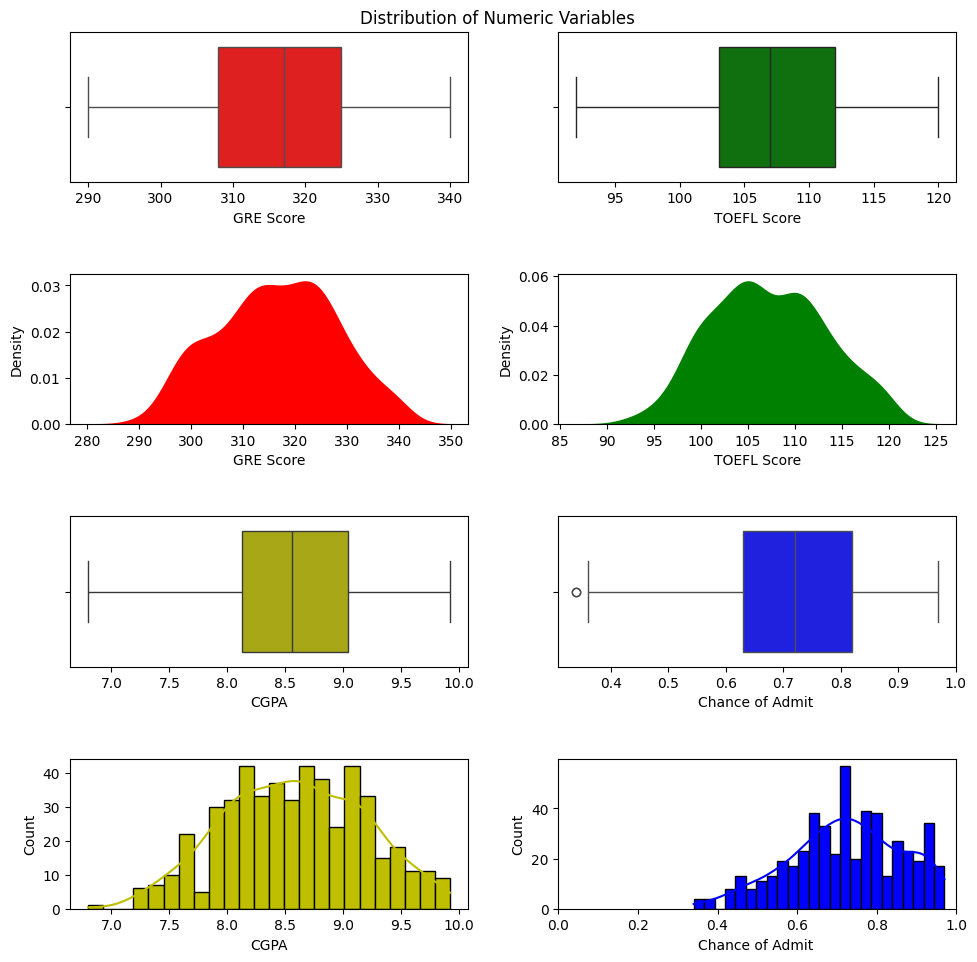

In [ ]:
#Numeric data:
numeric=['GRE Score', 'TOEFL Score', 'CGPA','Chance of Admit ']
fig, ax = plt.subplots(4,2)
plt.tight_layout()
fig.set_size_inches(10,10)
plt.suptitle('Distribution of Numeric Variables')
sns.boxplot(x=df['GRE Score'], ax=ax[0][0],color='r')
sns.boxplot(x=df['TOEFL Score'], ax=ax[0][1], color='g')
sns.kdeplot(x=df['GRE Score'], ax=ax[1][0], color='r', fill=True, alpha=1)
sns.kdeplot(x=df['TOEFL Score'], ax=ax[1][1], color='g', fill=True, alpha=1)
sns.boxplot(x=df['CGPA'], ax=ax[2][0],color='y')
sns.boxplot(x=df['Chance of Admit '], ax=ax[2][1],color='b')
sns.histplot(x=df['CGPA'],bins=24, ax=ax[3][0], color='y', alpha=1, kde = True)
sns.histplot(x=df['Chance of Admit '],bins=24, ax=ax[3][1],alpha=1, color='b', kde=True)
plt.xlim(0,1)
plt.show()

Further analyses:

In [ ]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

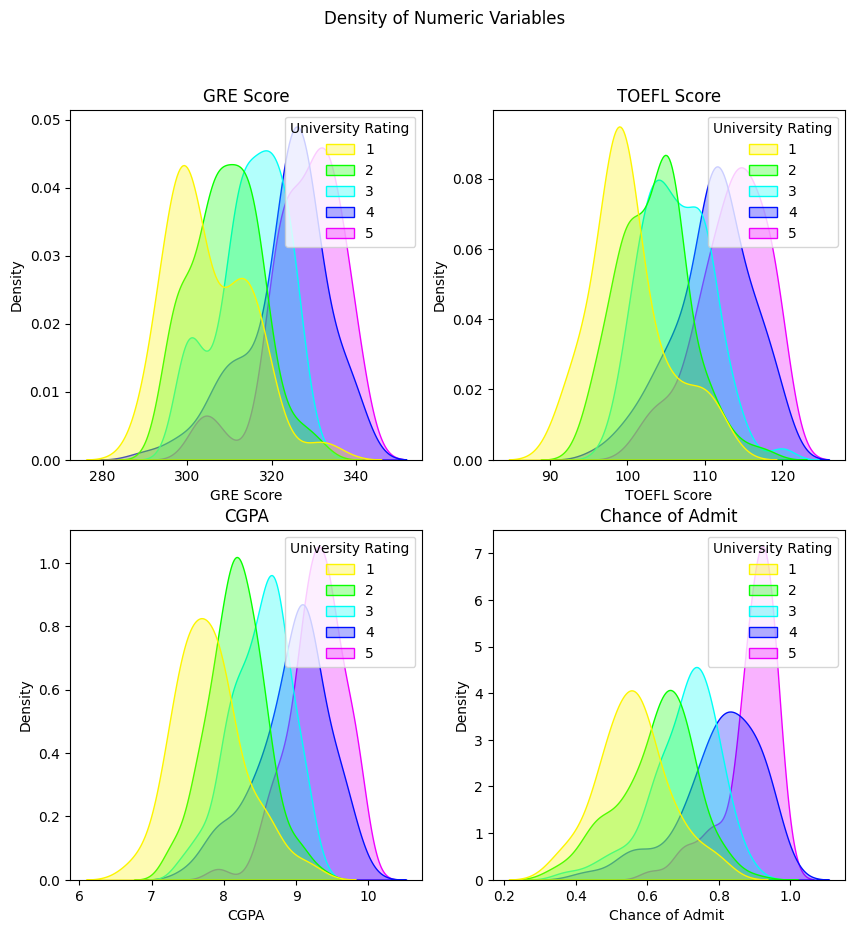

In [ ]:
fig , ax = plt.subplots(2,2)
plt.margins=0.2
fig.set_size_inches(10,10)
plt.suptitle('Density of Numeric Variables')
sns.kdeplot(data=df, x='GRE Score', ax=ax[0][0], common_norm=False,hue='University Rating' ,  fill=True,palette='hsv',  alpha=0.3).set_title('GRE Score')
sns.kdeplot(data=df, x='TOEFL Score', ax=ax[0][1], common_norm=False, hue='University Rating', fill=True, palette='hsv',  alpha=0.3).set_title('TOEFL Score')
sns.kdeplot(data=df, x='CGPA', ax=ax[1][0], common_norm=False, hue='University Rating', fill=True, palette='hsv',  alpha=0.3).set_title('CGPA')
sns.kdeplot(data=df, x='Chance of Admit ', ax=ax[1][1], common_norm=False, hue='University Rating', fill=True,palette='hsv',  alpha=0.3).set_title('Chance of Admit')
plt.show()

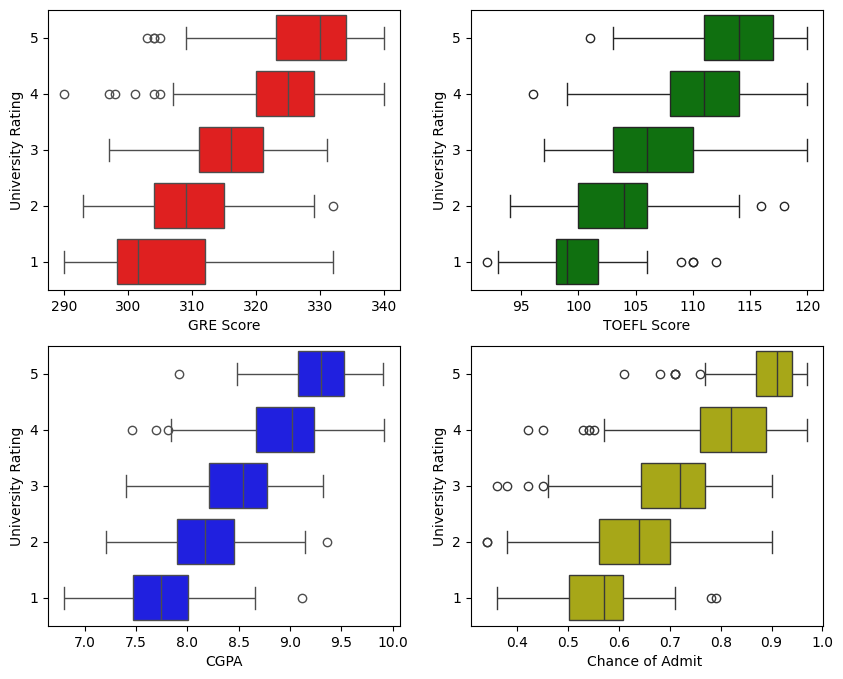

In [ ]:
fig=plt.figure(figsize=(10,8))
px=plt.subplot(221)
qx=plt.subplot(222)
rx=plt.subplot(223)
sx=plt.subplot(224)
sns.boxplot(x=df['GRE Score'], y=df['University Rating'], ax=px,color='r' ).invert_yaxis()
sns.boxplot(x=df['TOEFL Score'], y=df['University Rating'], ax=qx, color='g').invert_yaxis()
sns.boxplot(x=df['CGPA'], y=df['University Rating'], ax=rx,color='b').invert_yaxis()
sns.boxplot(x=df['Chance of Admit '], y=df['University Rating'], ax=sx, color='y').invert_yaxis()
plt.show()

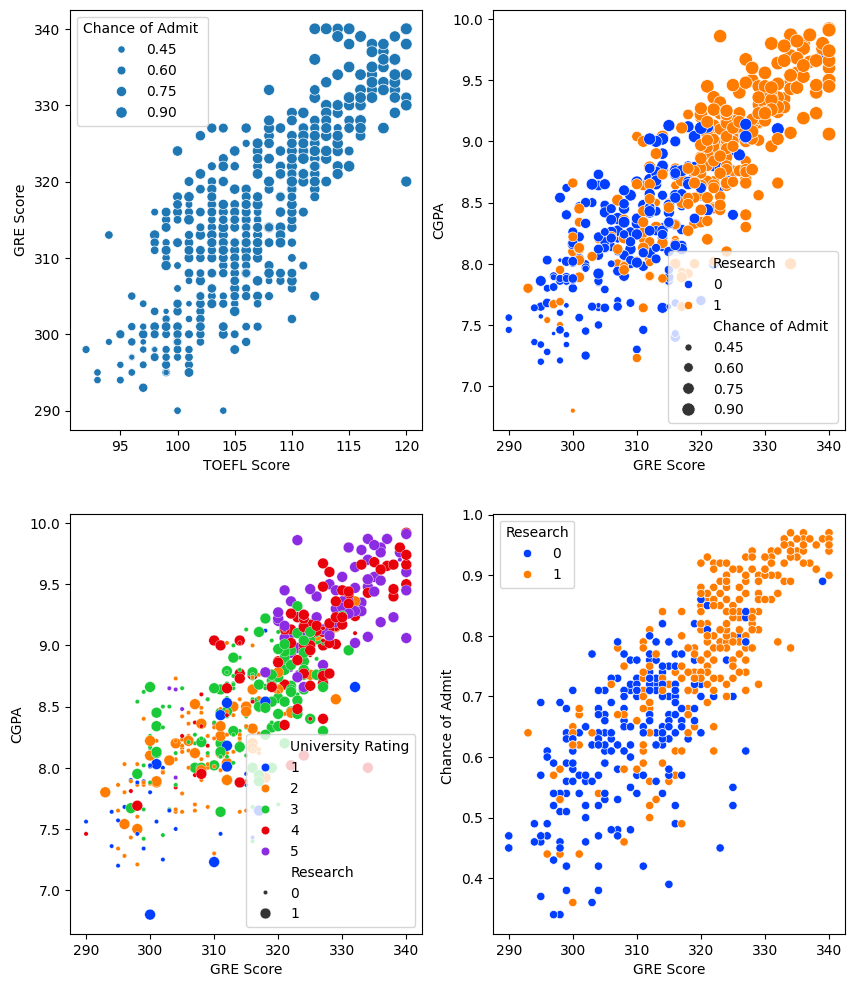

In [ ]:
plt.figure(figsize=(10,12))
sx=plt.subplot(221)
tx=plt.subplot(222)
ux=plt.subplot(223)
vx=plt.subplot(224)
sns.scatterplot(size=df['Chance of Admit '],ax=sx, y=df['GRE Score'], x=df['TOEFL Score'], palette= 'bright' )
sns.scatterplot(x=df['GRE Score'], y=df['CGPA'], hue=df['Research'], size=df['Chance of Admit '], sizes=(10,100),palette= 'bright', ax=tx)
sns.scatterplot(x=df['GRE Score'], y=df['CGPA'],size=df.Research, sizes = (60,10), hue=df['University Rating'], palette= 'bright',ax=ux)
sns.scatterplot(x=df['GRE Score'], y=df['Chance of Admit '], hue = df['Research'], palette= 'bright',ax=vx)
plt.show()

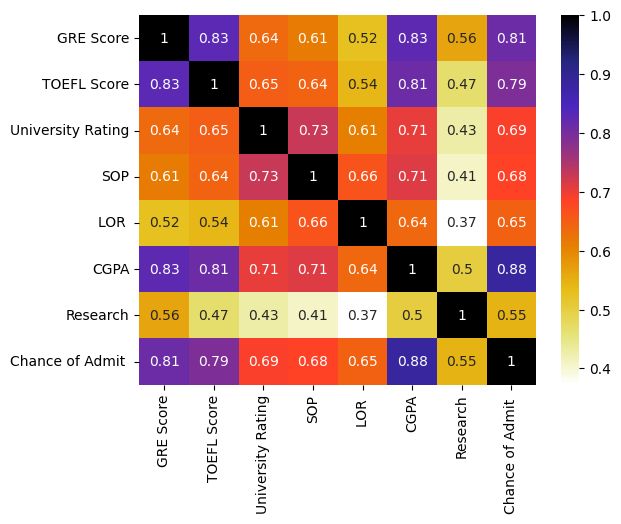

In [ ]:
sns.heatmap(df.loc[:,df.columns != 'Serial No.'].corr(), annot=True, cmap='CMRmap_r')
plt.xticks(rotation=90)
plt.show()

All numerics are positive correlated

In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/Jamboree_Admission.csv')
df1.shape

(500, 9)

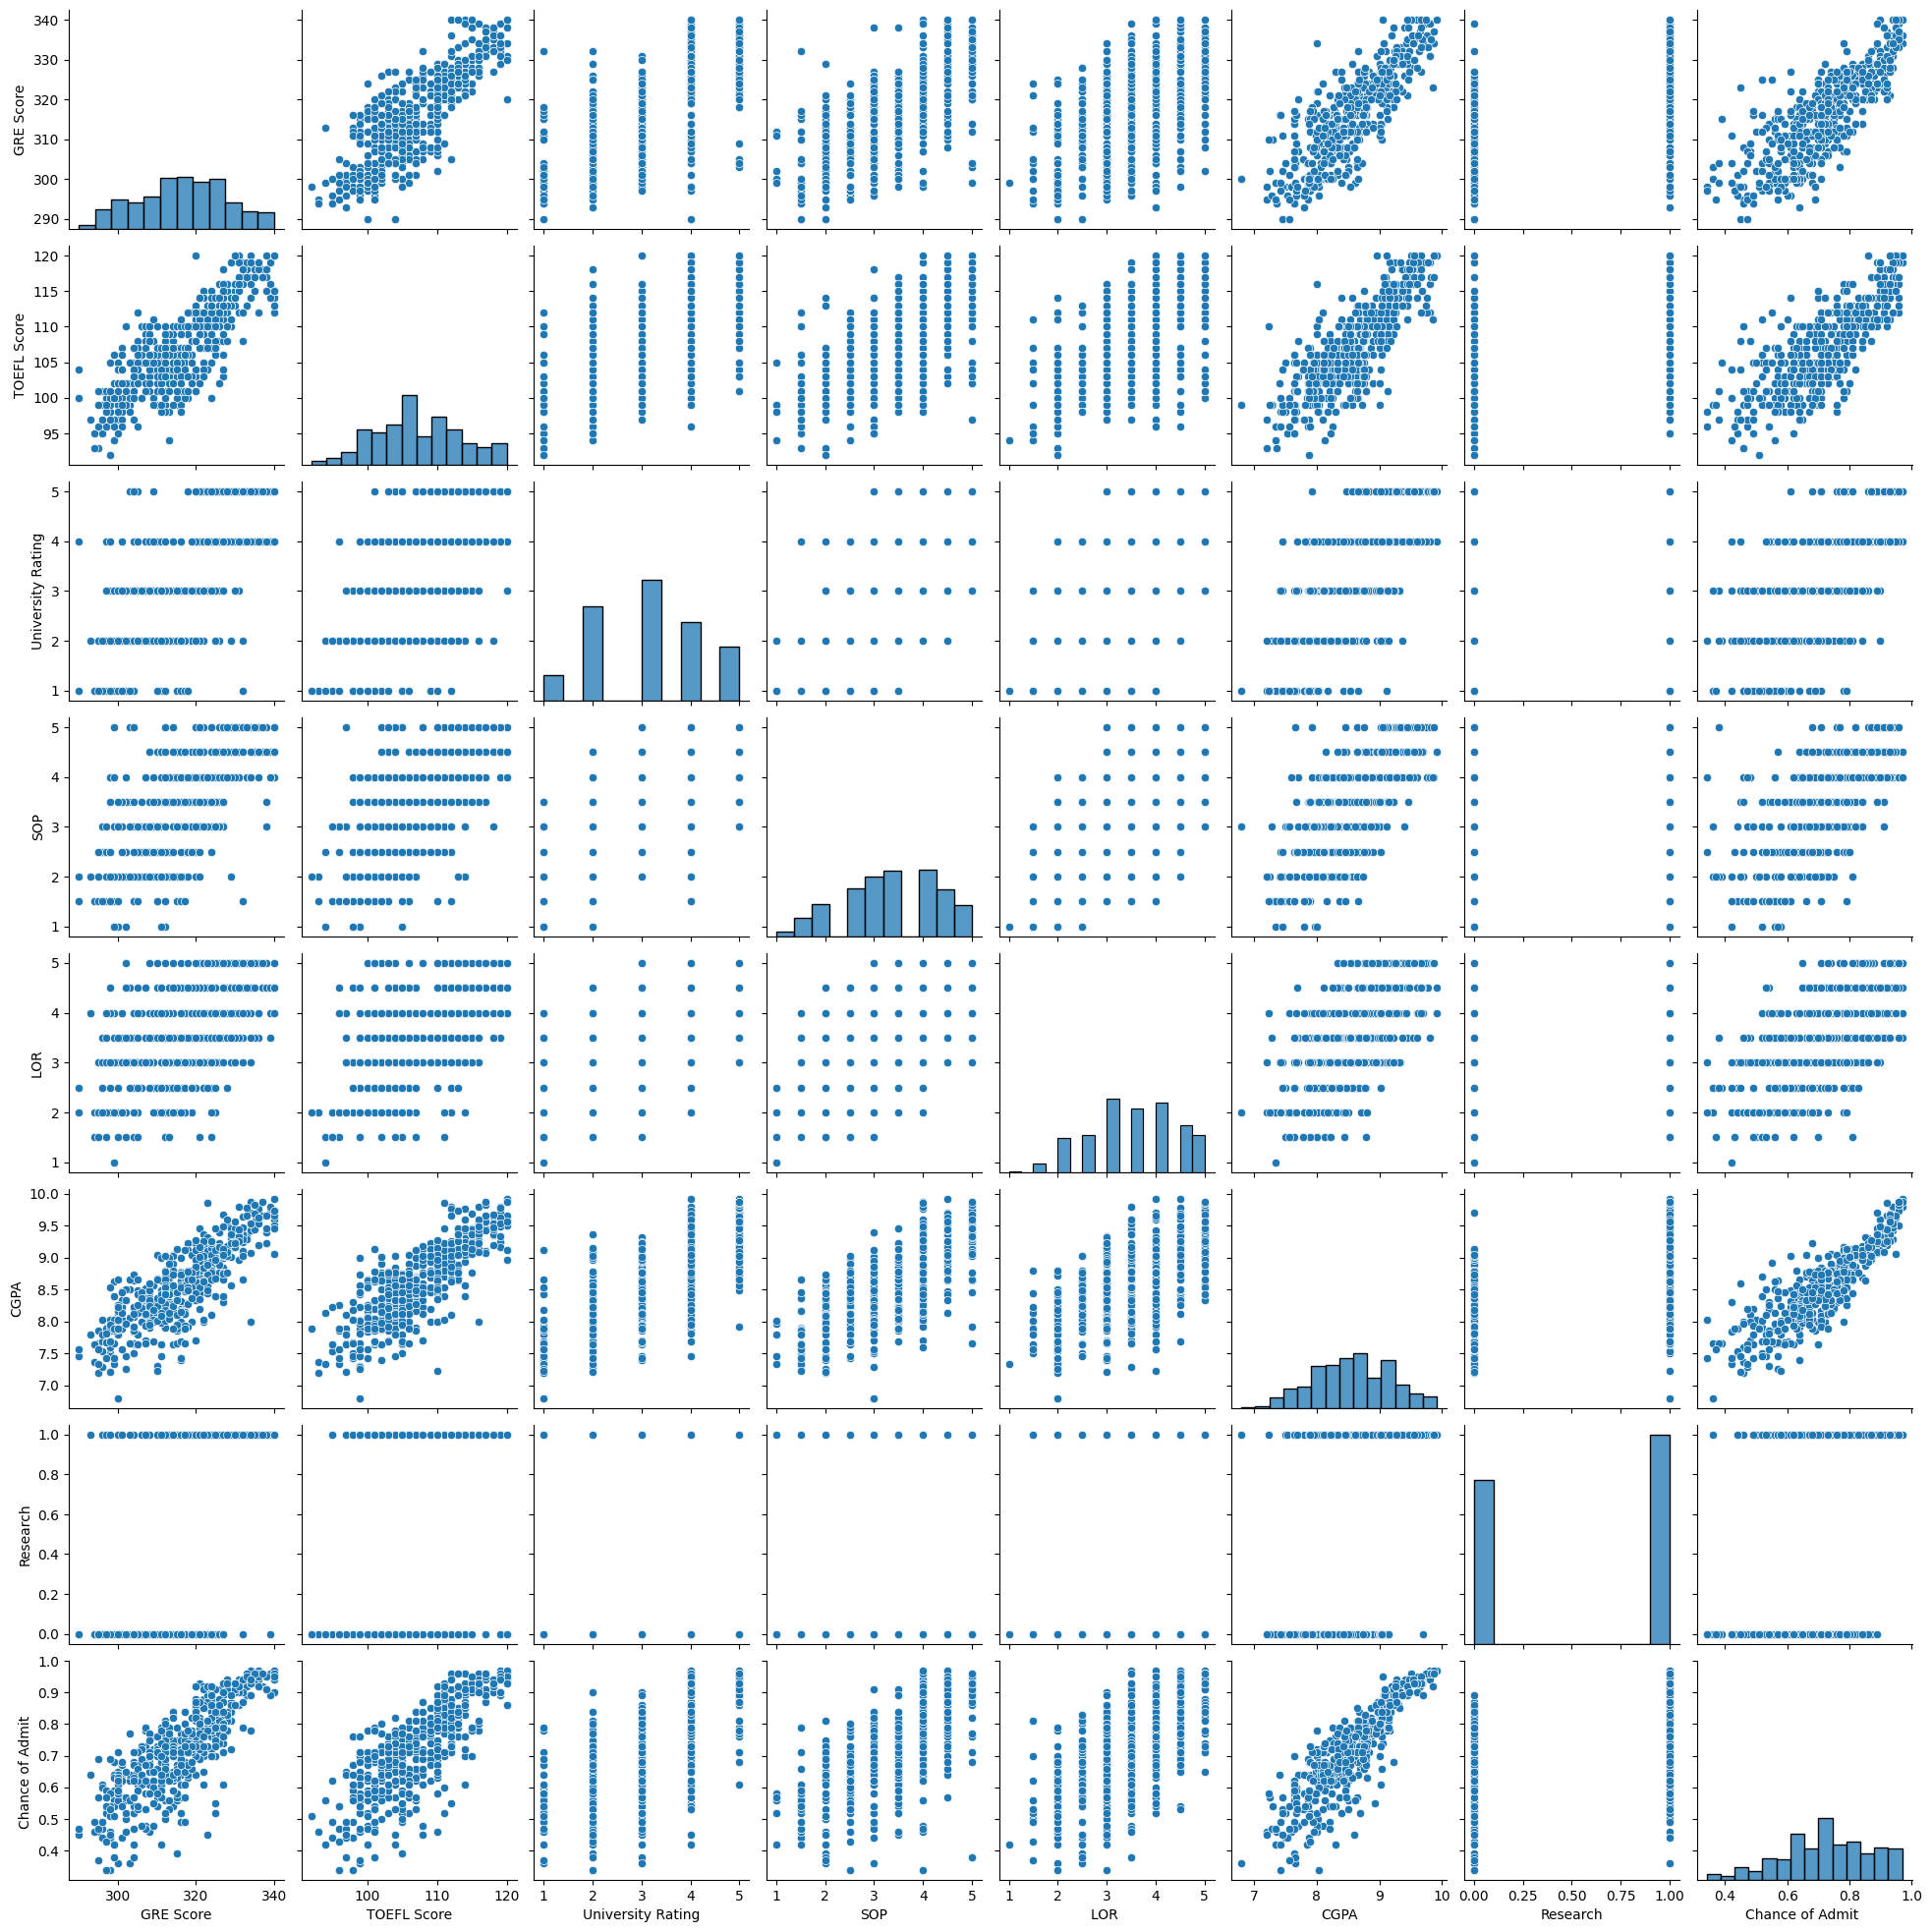

In [ ]:
sns.pairplot(df1.loc[:,df1.columns != 'Serial No.'])
plt.show()

# Preparing data for processing:

In [ ]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
df.rename( columns={'LOR ':'LOR'}, inplace=True)

In [ ]:
df.rename( columns={'Chance of Admit ':'Chance of Admit'}, inplace=True)

In [ ]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance of Admit'],
      dtype='object')

Separating features and output datasets:

In [ ]:
Y=df['Chance of Admit']
X=df.drop(columns=['Chance of Admit'], axis=1)

In [ ]:
X.shape, Y.shape

((500, 7), (500,))

In [ ]:
X.dtypes

,0
GRE Score,int64
TOEFL Score,int64
University Rating,category
SOP,category
LOR,category
CGPA,float64
Research,category


In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
GRE Score,500.0,316.47200,11.295148,290.0,308.0000,317.00,325.00,340.00
TOEFL Score,500.0,107.19200,6.081868,92.0,103.0000,107.00,112.00,120.00
CGPA,500.0,8.57644,0.604813,6.8,8.1275,8.56,9.04,9.92


In [ ]:
X.describe(include='category')

,University Rating,SOP,LOR,Research
count,500,500.0,500.0,500
unique,5,9.0,9.0,2
top,3,4.0,3.0,1
freq,162,89.0,99.0,280


In [ ]:
X.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='object')

Columns 'Research', 'SOP', 'LOR', and 'University Rating' are of type category. To apply ML they need to be encoded as numeric. From data discription provided these features except 'Research' are ordinal. 'Research is a binary. we use OrdinalEncoder for encoding.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ord=OrdinalEncoder()
X['SOP']=ord.fit_transform(X[['SOP']])
X['LOR']=ord.fit_transform(X[['LOR']])
X['University Rating']=ord.fit_transform(X[['University Rating']])
X['Research']=ord.fit_transform(X[['Research']])

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    float64
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 27.5 KB


In [ ]:
Y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: Chance of Admit
Non-Null Count  Dtype  
--------------  -----  
500 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
GRE Score,500.0,316.47200,11.295148,290.0,308.0000,317.00,325.00,340.00
TOEFL Score,500.0,107.19200,6.081868,92.0,103.0000,107.00,112.00,120.00
University Rating,500.0,2.11400,1.143512,0.0,1.0000,2.00,3.00,4.00
SOP,500.0,4.74800,1.982007,0.0,3.0000,5.00,6.00,8.00
LOR,500.0,4.96800,1.850899,0.0,4.0000,5.00,6.00,8.00
CGPA,500.0,8.57644,0.604813,6.8,8.1275,8.56,9.04,9.92
Research,500.0,0.56000,0.496884,0.0,0.0000,1.00,1.00,1.00


X.describe() suggests that the features have diverse spreads. The spread need to be uniform before any ML application. we use MinMax scaler to normalize. This precedes train-test split, as the two slices need to be independent.

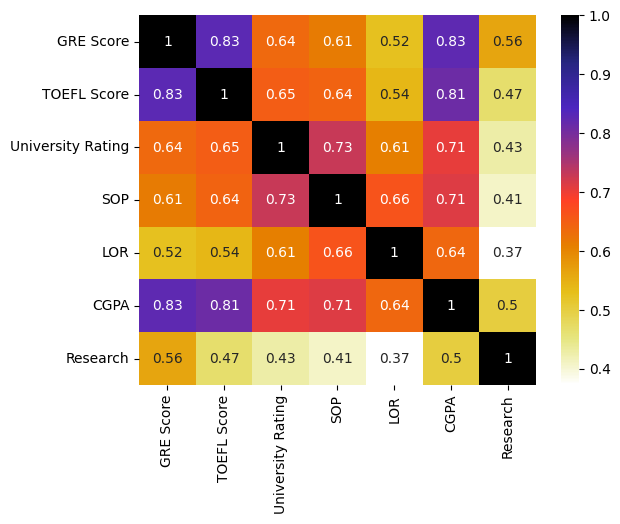

In [ ]:
sns.heatmap(X.corr(), annot=True, cmap='CMRmap_r')
plt.xticks(rotation=90)
plt.show()

-Features 'GRE Score', 'TOEFL Score', and 'CGPA' demonstrate strong positive correlation. We combine these to create a new feature, 'Score' as under:

Score = ['GRE Score'/ 340, TOEFL Score/ 120, and 'CGPA'/ 10]/3

In [ ]:
X['Score']=((X['GRE Score']/340)+(X['TOEFL Score']/120)+(X['CGPA']/10))/3

In [ ]:
X.Score.describe()

,Score
count,500.000000
mean,0.893904
std,0.045220
min,0.787549
25%,0.862632
50%,0.889761
75%,0.926729
max,0.997333


Dropping 'GRE Score', 'TOEFL Score', and 'CGPA' from X

In [ ]:
X.drop(columns=['GRE Score', 'TOEFL Score','CGPA'], axis=1, inplace=True)

In [ ]:
X.columns

Index(['University Rating', 'SOP', 'LOR', 'Research', 'Score'], dtype='object')

Spliting data into train and test. (80:20)

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest=train_test_split(X, Y, test_size=0.2, random_state=31)

The data is sparse, there is need to normalize.

In [ ]:
xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
University Rating,400.0,2.112500,1.128285,0.000000,1.000000,2.000000,3.000000,4.000000
SOP,400.0,4.760000,1.961382,0.000000,3.000000,5.000000,6.000000,8.000000
LOR,400.0,4.942500,1.867596,0.000000,4.000000,5.000000,6.000000,8.000000
Research,400.0,0.562500,0.496700,0.000000,0.000000,1.000000,1.000000,1.000000
Score,400.0,0.894404,0.045420,0.787549,0.863216,0.891556,0.926685,0.997333


In [ ]:
xtest.describe().T

,count,mean,std,min,25%,50%,75%,max
University Rating,100.0,2.1200,1.208388,0.000000,1.000000,2.000000,3.000000,4.000000
SOP,100.0,4.7000,2.071939,0.000000,3.000000,5.000000,6.000000,8.000000
LOR,100.0,5.0700,1.788035,1.000000,4.000000,5.000000,6.000000,8.000000
Research,100.0,0.5500,0.500000,0.000000,0.000000,1.000000,1.000000,1.000000
Score,100.0,0.8919,0.044584,0.791902,0.860116,0.884895,0.926908,0.983026


Using Standard scaler:

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
xtrain=scaler.fit_transform(xtrain)

In [ ]:
xtrain=pd.DataFrame(xtrain, columns=X.columns)

In [ ]:
xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
University Rating,400.0,1.820766e-16,1.001252,-1.874656,-0.987245,-0.099834,0.787577,1.674988
SOP,400.0,9.325873e-17,1.001252,-2.429900,-0.898450,0.122516,0.632999,1.653966
LOR,400.0,6.439294e-17,1.001252,-2.649765,-0.505292,0.030827,0.566945,1.639182
Research,400.0,0.000000e+00,1.001252,-1.133893,-1.133893,0.881917,0.881917,0.881917
Score,400.0,-7.105427e-17,1.001252,-2.355579,-0.687543,-0.062804,0.711601,2.269019


In [ ]:
xtest=scaler.fit_transform(xtest)

In [ ]:
xtest=pd.DataFrame(xtest, columns=X.columns)

In [ ]:
xtest.describe().T

,count,mean,std,min,25%,50%,75%,max
University Rating,100.0,-1.065814e-16,1.005038,-1.763241,-0.931524,-0.099806,0.731912,1.563629
SOP,100.0,-5.551115e-17,1.005038,-2.279835,-0.824621,0.145521,0.630593,1.600735
LOR,100.0,1.776357e-17,1.005038,-2.287709,-0.601437,-0.039346,0.522744,1.646925
Research,100.0,-1.554312e-16,1.005038,-1.105542,-1.105542,0.904534,0.904534,0.904534
Score,100.0,-3.552714e-17,1.005038,-2.254202,-0.716486,-0.157896,0.789184,2.054216


In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
lrmodel=lr.fit(xtrain, ytrain)

In [ ]:
lrmodel.coef_

array([0.00450893, 0.00749705, 0.01856237, 0.01191149, 0.09866725])

In [ ]:
lrmodel.intercept_

0.7224

In [ ]:
y_h=lr.predict(xtest)

In [ ]:
from sklearn.metrics import r2_score
rsqtrain=r2_score(ytrain, lrmodel.predict(xtrain))
rsqred=r2_score(ytest, y_h)
rsqtrain, rsqred

(0.8062443269499179, 0.8308403028497657)

In [ ]:
test_adj_r2=1-(1-rsqred)*((xtest.shape[0]-1)/(xtest.shape[0]-xtest.shape[1]-1))
train_adj_r2=1-(1-rsqtrain)*((xtrain.shape[0]-1)/(xtrain.shape[0]-xtrain.shape[1]-1))
train_adj_r2, test_adj_r2

(0.8037854986117189, 0.8218424466183702)

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(ytest, y_h)

0.003310487413572544

In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(ytest, y_h)

0.0398497134647719

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(ytest, y_h)

0.06484199306275244

In [ ]:
lrm=pd.DataFrame(lrmodel.coef_, columns=['Coefficients'])

In [ ]:
lrm['Features']=xtrain.columns

Feature- 'Score' is most dominant, followed by LOR, Research, and SOP in the order. University rating is least affecting Feature.

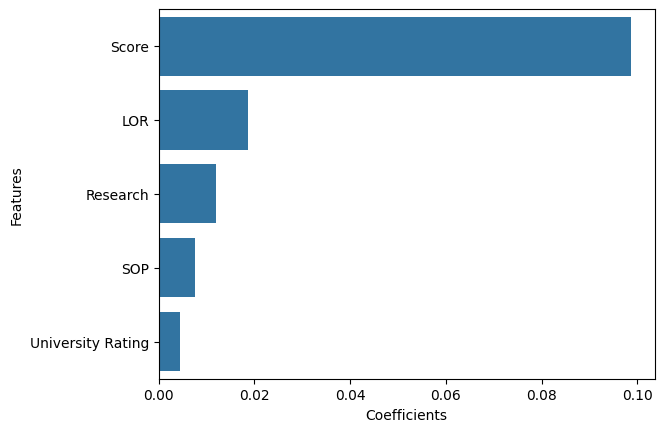

In [ ]:
sns.barplot(y=lrm.sort_values(by='Coefficients', ascending=False).Features, x=lrm.sort_values(by='Coefficients', ascending=False).Coefficients)
plt.show()

In [ ]:
xtrain.describe()

,University Rating,SOP,LOR,Research,Score
count,400.000000,400.000000,400.000000,400.0000,400.000000
mean,0.528125,0.595000,0.617812,0.5625,0.509359
std,0.282071,0.245173,0.233449,0.4967,0.216506
min,0.000000,0.000000,0.000000,0.0000,0.000000
25%,0.250000,0.375000,0.500000,0.0000,0.360688
50%,0.500000,0.625000,0.625000,1.0000,0.495778
75%,0.750000,0.750000,0.750000,1.0000,0.663232
max,1.000000,1.000000,1.000000,1.0000,1.000000


Testing the assumptions of linear regression.
- VIF

All VIF values are less than 5.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame()
vif['Features']=xtrain.columns
vif['VIF']=[variance_inflation_factor(xtrain.values, i) for i in range(xtrain.shape[1])]
vif

,Features,VIF
0,University Rating,2.467928
1,SOP,2.841445
2,LOR,2.052877
3,Research,1.380374
4,Score,2.792995


Mean of residues to be zero.

Mean of residues is very small 0.0033

In [ ]:
resi_mean=np.mean(y_h-ytest)
resi_mean

0.0033000000000000377

Test for Homoscedasticity

The plot displays little homoscedasticity

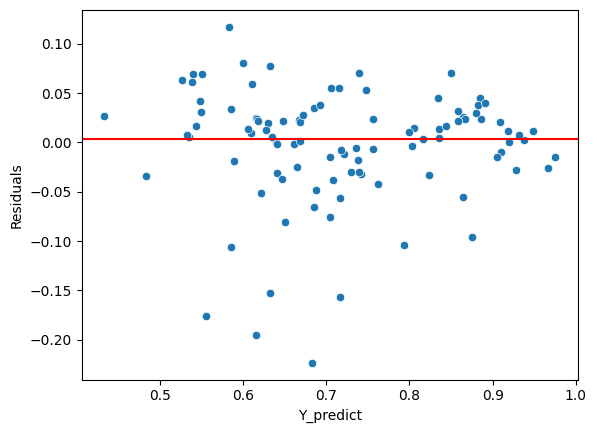

In [ ]:
resid=ytest-y_h
sns.scatterplot(x=y_h, y=resid)
plt.axhline(y=resi_mean, color='r')
plt.xlabel('Y_predict')
plt.ylabel('Residuals')
plt.show()

Linearity between dependant and independant variables.

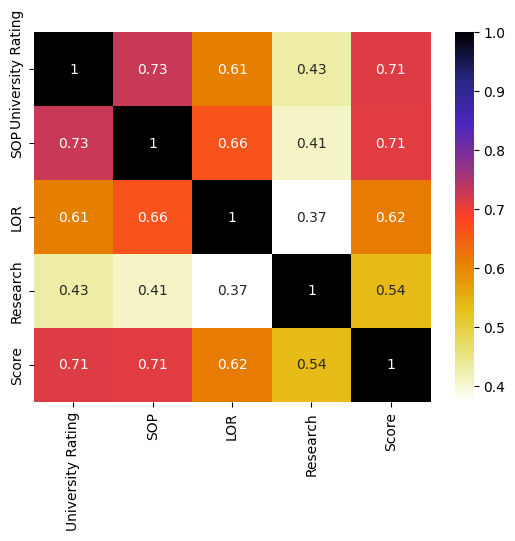

In [ ]:
sns.heatmap(X.corr(), annot=True, cmap='CMRmap_r')
plt.xticks(rotation=90)
plt.show()

Test for normality of residues:

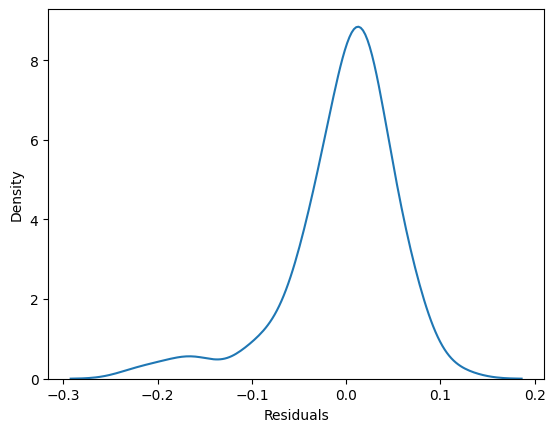

In [ ]:
sns.kdeplot(resid)
plt.xlabel('Residuals')
plt.show()

#Insights:
- The basic Linear regression model looks good with an acceptable accuracy of 78%.
- CGPA, GRE and TOEFL scores have high collinearity which led to lower accuracy.
- Feature 'Score' the derived feature is the most important among the features followed by the LOR and Research
- The univerisity ratings and SOP doesn't have much impact on the outcome
- A good research background and strong LOR and SOP have a significantly higher likelihood of getting an admit.

#Recommendations:
- Additional parameters like academic competitions, Extra-curriculars, sports, social work, etc. if added may improve the accuracy of the model.
- The data pertaining to failure to gain admit is vital and should prove to be useful in making model better.